# Exercițiu LP2 — Setul de date Penguins

**de lucru individual — aprox. 30 minute**

Ați exersat în LP2 explorarea structurii datelor, curățarea lor, statisticile descriptive și principalele tipuri de grafice, pe setul de date Galton. În acest exercițiu aplicați aceleași tehnici pe un set de date nou: **Palmer Penguins** — măsurători pentru 344 de pinguini din trei specii, colectate în Arhipelagul Palmer, Antarctica.

**Variabile:**
- `species` — specia pinguinului: Adelie, Chinstrap sau Gentoo
- `island` — insula pe care a fost observat: Biscoe, Dream sau Torgersen
- `bill_length_mm`, `bill_depth_mm` — lungimea și adâncimea ciocului (mm)
- `flipper_length_mm` — lungimea aripioarei (mm)
- `body_mass_g` — masa corporală (g)
- `sex` — sexul pinguinului

### Instrucțiuni
- Lucrați **individual**, timp de aproximativ 30 de minute.
- Completați celulele marcate cu `# TODO`, folosind comenzile exersate în LP2.
- Nu este nevoie să scrieți cod perfect — scopul e să exersați, nu să obțineți un rezultat impecabil.
- Dacă rămâneți blocați mai mult de 4-5 minute la o cerință, treceți la următoarea și reveniți la final.

### Pregătire — rulați celula de mai jos (nu necesită modificări)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

penguins_df = sns.load_dataset('penguins')
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Sarcina 1 — Explorarea structurii datelor (~5 min)

**1.1** Afișați dimensiunea setului de date (număr de rânduri și coloane).

In [2]:
penguins_df.shape


(344, 7)

**1.2** Afișați tipul de date al fiecărei coloane.

In [3]:
penguins_df.dtypes


,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object


**1.3** Afișați un rezumat descriptiv pentru **toate** variabilele (numerice și categoriale).

In [9]:
penguins_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


**1.4** Câte specii distincte de pinguini există în setul de date? Care sunt ele? *(indiciu: `nunique()` și `unique()`)*

In [12]:
print(penguins_df['species'	].nunique())
print(penguins_df['species'	].unique())



3
['Adelie' 'Chinstrap' 'Gentoo']


## Sarcina 2 — Manipularea datelor (~5 min)

**2.1** Selectați și afișați doar coloanele `species`, `island` și `body_mass_g`.

In [18]:
df_selection = penguins_df[['species', 'island', 'body_mass_g']]
print(df_selection)


    species     island  body_mass_g
0    Adelie  Torgersen       3750.0
1    Adelie  Torgersen       3800.0
2    Adelie  Torgersen       3250.0
3    Adelie  Torgersen          NaN
4    Adelie  Torgersen       3450.0
..      ...        ...          ...
339  Gentoo     Biscoe          NaN
340  Gentoo     Biscoe       4850.0
341  Gentoo     Biscoe       5750.0
342  Gentoo     Biscoe       5200.0
343  Gentoo     Biscoe       5400.0

[344 rows x 3 columns]


**2.2** Filtrați setul de date pentru a păstra doar pinguinii din specia `Gentoo`. Salvați rezultatul într-o variabilă nouă, `gentoo_df`.

In [21]:
gentoo_df=penguins_df[penguins_df['species']=='Gentoo']
print(gentoo_df)


    species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
220  Gentoo  Biscoe            46.1           13.2              211.0   
221  Gentoo  Biscoe            50.0           16.3              230.0   
222  Gentoo  Biscoe            48.7           14.1              210.0   
223  Gentoo  Biscoe            50.0           15.2              218.0   
224  Gentoo  Biscoe            47.6           14.5              215.0   
..      ...     ...             ...            ...                ...   
339  Gentoo  Biscoe             NaN            NaN                NaN   
340  Gentoo  Biscoe            46.8           14.3              215.0   
341  Gentoo  Biscoe            50.4           15.7              222.0   
342  Gentoo  Biscoe            45.2           14.8              212.0   
343  Gentoo  Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
220       4500.0  Female  
221       5700.0    Male  
222       4450.0  Female  
223       5700.

**2.3** Selectați un eșantion aleator de 10 rânduri din setul de date original.

In [24]:
esantion_df=penguins_df.sample(10)
print(esantion_df)


       species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
165  Chinstrap      Dream            52.0           18.1              201.0   
194  Chinstrap      Dream            50.9           19.1              196.0   
35      Adelie      Dream            39.2           21.1              196.0   
108     Adelie     Biscoe            38.1           17.0              181.0   
208  Chinstrap      Dream            45.2           16.6              191.0   
294     Gentoo     Biscoe            46.4           15.0              216.0   
19      Adelie  Torgersen            46.0           21.5              194.0   
143     Adelie      Dream            40.7           17.0              190.0   
202  Chinstrap      Dream            48.1           16.4              199.0   
182  Chinstrap      Dream            40.9           16.6              187.0   

     body_mass_g     sex  
165       4050.0    Male  
194       3550.0    Male  
35        4150.0    Male  
108       3175.0  Fema

## Sarcina 3 — Curățarea datelor (~5 min)

**3.1** Câte valori lipsă (`NaN`) are fiecare coloană?

In [26]:
penguins_df.isna().sum()


,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


**3.2** Eliminați rândurile cu valori lipsă și salvați rezultatul într-un nou DataFrame, `penguins_clean`.

In [27]:
penguins_clean=penguins_df.dropna()


**3.3** Verificați dimensiunea noului set de date. Câte rânduri au fost eliminate față de setul inițial?

In [28]:
penguins_clean.shape


(333, 7)

## Sarcina 4 — Statistici descriptive (~7 min)

*Folosiți `penguins_clean` pentru sarcinile de mai jos.*

**4.1** Calculați masa corporală medie (`body_mass_g`), pentru fiecare specie.

In [30]:
mean_mass=penguins_clean['body_mass_g'].mean()
print(mean_mass)


4207.057057057057


**4.2** Care specie are, în medie, cea mai lungă aripioară (`flipper_length_mm`)?

In [38]:
penguins_clean.groupby('species')['flipper_length_mm'].mean().sort_values(ascending=False)

,flipper_length_mm
species,
Gentoo,217.235294
Chinstrap,195.823529
Adelie,190.102740


**4.3** Afișați frecvența (numărul de observații) pentru fiecare insulă (`island`).

In [41]:
penguins_clean.groupby('island')['island'].count()
penguins_clean['island'].value_counts()

,count
island,
Biscoe,163
Dream,123
Torgersen,47


**4.4** Ce procent din pinguini sunt masculi și ce procent sunt femele, în setul curățat? *(indiciu: `value_counts(normalize=True)`)*

In [42]:
penguins_clean['sex'].value_counts(normalize=True)


,proportion
sex,
Male,0.504505
Female,0.495495


## Sarcina 5 — Vizualizare (~8 min)

*Folosiți `penguins_clean` pentru graficele de mai jos.*

**5.1** Realizați un `countplot` pentru distribuția speciilor (`species`).

<Axes: xlabel='species', ylabel='count'>

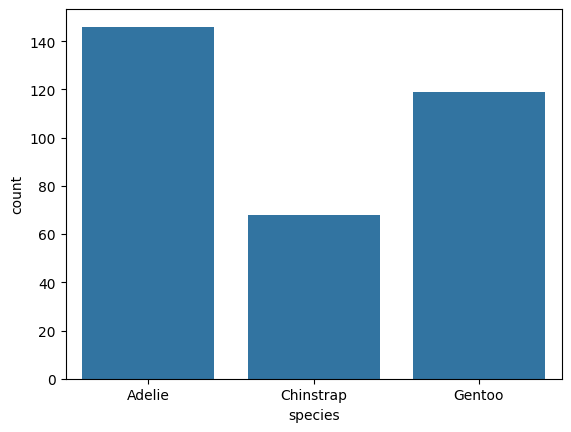

In [46]:
#penguins_clean.columns
sns.countplot(data=penguins_clean, x='species')

**5.2** Realizați un `barplot` cu masa corporală medie pe specie, colorat (`hue`) în funcție de sex.

<Axes: xlabel='species', ylabel='body_mass_g'>

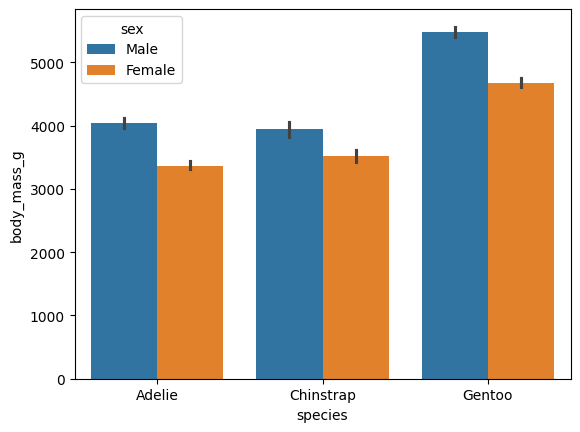

In [47]:
sns.barplot(data=penguins_clean, x='species', y='body_mass_g', hue='sex')


**5.3** Realizați un grafic de tip `relplot` (scatter) între `bill_length_mm` și `bill_depth_mm`, colorat după `species`.

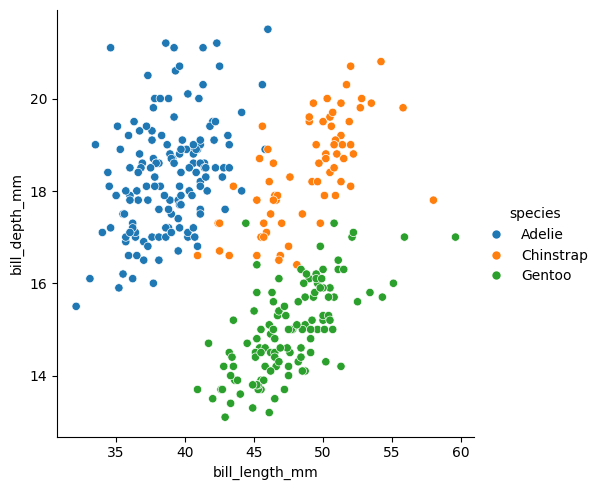

In [48]:

sns.relplot(data=penguins_clean, x='bill_length_mm', y='bill_depth_mm', hue='species', kind='scatter')


**5.4** Realizați un `boxplot` sau un `violinplot` (folosind `catplot`) pentru `flipper_length_mm`, pe fiecare specie.

<Axes: xlabel='species', ylabel='flipper_length_mm'>

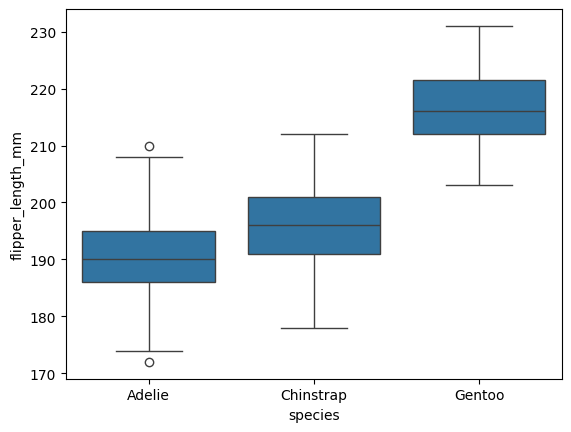

In [50]:
sns.boxplot(data=penguins_clean, x='species', y='flipper_length_mm')
#sns.violinplot(data=penguins_clean, x='species', y='flipper_length_mm')


**5.5** Realizați un `heatmap` cu matricea de corelații a variabilelor numerice.

<Axes: >

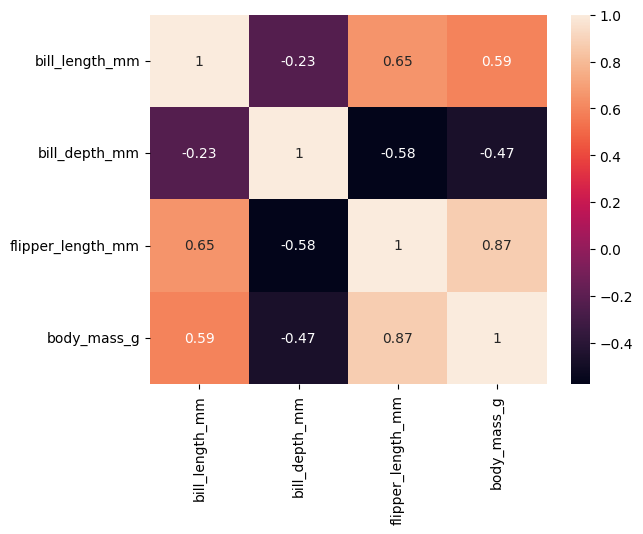

In [58]:
df_numerice=penguins_clean.select_dtypes(include=np.number)
df_numerice.corr()
sns.heatmap(df_numerice.corr(),annot=True)




## Bonus (opțional, dacă ați terminat mai devreme)

- Există diferențe de masă corporală între insule (`island`)? Realizați un `barplot` sau un `boxplot` pentru a verifica.
- Realizați un `pairplot` cu `hue='species'` pentru întregul set curățat — ce observați?

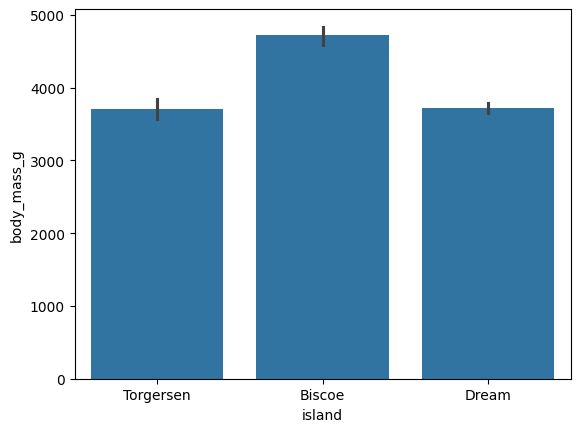

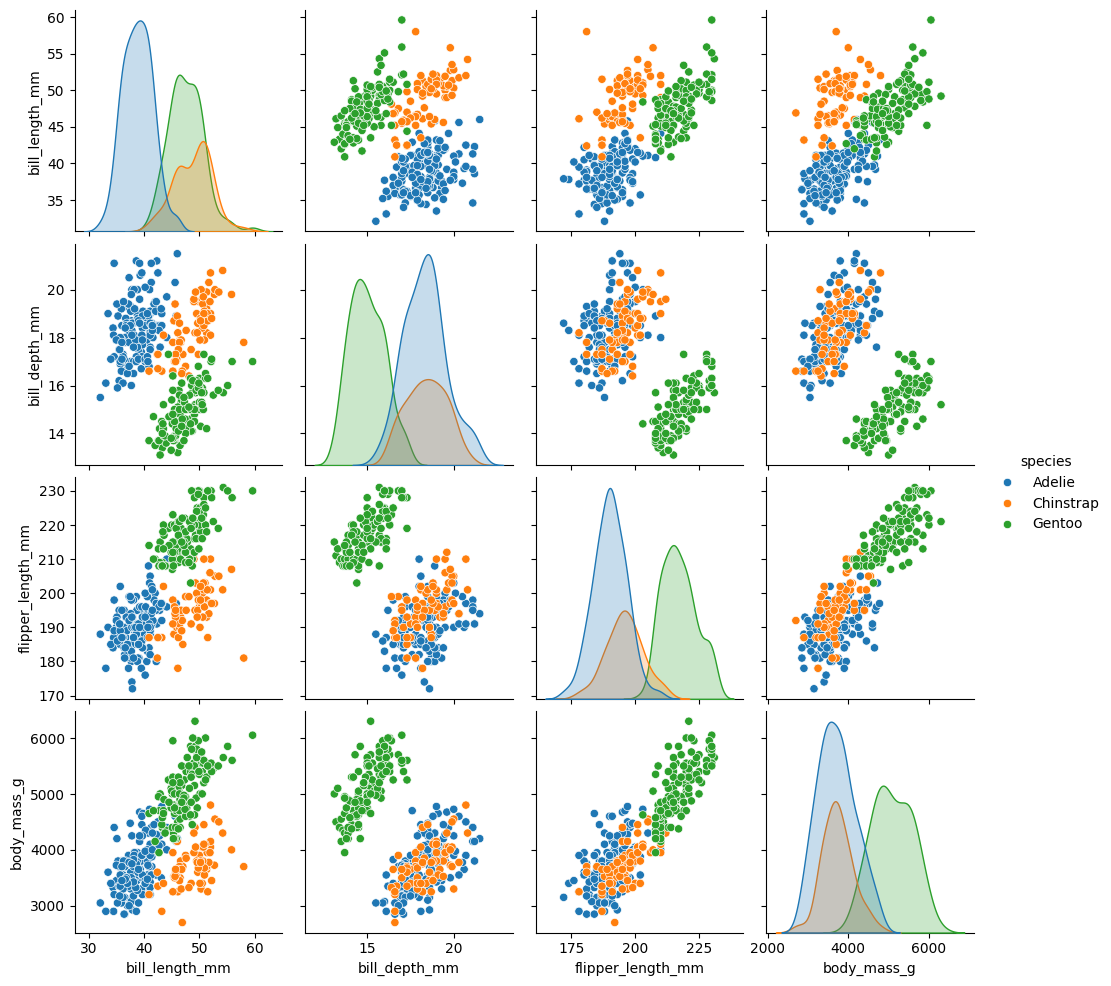

In [62]:
sns.barplot(data=penguins_clean, x='island', y='body_mass_g')
#sns.boxplot(data=penguins_clean, x='island', y='body_mass_g')

sns.pairplot(data=penguins_clean, hue='species')

